In [ ]:

import requests
import io
import xarray as xr


API_BASE_URL = "https://matilda-proxy-315466959166.europe-west3.run.app"


def _looks_like_tiff(raw_bytes):
    """Quick sanity check for TIFF byte signatures."""
    header = io.BytesIO(raw_bytes).read(4)
    return header in (b"II*\x00", b"MM\x00*")


def download_dem_from_proxy(lat=None, lon=None, buffer_m=40000, asset="USGS/SRTMGL1_003", geometry=None):
    
    """Download a DEM GeoTIFF from the proxy API using either a point (lat/lon) or a geometry.

        Args:
            lat (float | None): Latitude of the target point. Required if `geometry` is not provided.
            lon (float | None): Longitude of the target point. Required if `geometry` is not provided.
            buffer_m (int): Buffer radius in meters around the point/geometry. Defaults to 40000.
            asset (str): Earth Engine DEM asset identifier. Defaults to "USGS/SRTMGL1_003".
            geometry (dict | None): GeoJSON-like geometry (e.g., Point or Polygon). If provided, `lat`/`lon`
                are ignored.

        Raises:
            ValueError: If neither `geometry` nor both `lat` and `lon` are provided.
            RuntimeError: If the HTTP request fails.
            RuntimeError: If the proxy returns an empty response.
            RuntimeError: If the response is not a TIFF file.

        Returns:
            None: Saves the DEM to `gebiets_dem.tif` in the current working directory.
        """
    payload = {
        "buffer_m": buffer_m,
        "asset": asset,
    }

    if geometry is not None:
        payload["geometry"] = geometry
        print(f"Fordere DEM für geometry={geometry.get('type')} an (asset={asset})...")
    else:
        if lat is None or lon is None:
            raise ValueError("Bitte entweder geometry oder lat/lon angeben.")
        payload["lat"] = lat
        payload["lon"] = lon
        print(f"Fordere DEM für {lat}, {lon} an (asset={asset})...")

    try:
        response = requests.post(
            f"{API_BASE_URL}/download-dem",
            json=payload,
            timeout=180,
        )
        response.raise_for_status()
    except requests.RequestException as exc:
        raise RuntimeError(f"DEM-Download fehlgeschlagen: {exc}") from exc

    if not response.content:
        raise RuntimeError("Leere Antwort vom Proxy erhalten.")

    if not _looks_like_tiff(response.content):
        content_type = response.headers.get("Content-Type", "unbekannt")
        raise RuntimeError(
            f"Antwort ist keine TIFF-Datei (Content-Type: {content_type}). "
            f"Server-Antwort: {response.text[:300]}"
        )

    with open("gebiets_dem.tif", "wb") as f:
        f.write(response.content)

    print("Download erfolgreich! Datei gespeichert als 'gebiets_dem.tif'")



In [7]:
download_dem_from_proxy(lat=46.81, lon=9.84, asset="USGS/SRTMGL1_003")

Fordere DEM für 46.81, 9.84 an (asset=USGS/SRTMGL1_003)...
Download erfolgreich! Datei gespeichert als 'gebiets_dem.tif'


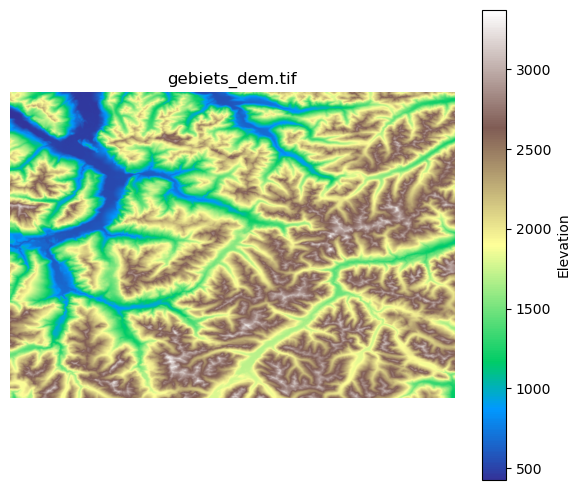

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import rasterio


with rasterio.open("gebiets_dem.tif") as src:
    dem = src.read(1)

plt.figure(figsize=(6, 5))
plt.imshow(dem, cmap="terrain")
plt.colorbar(label="Elevation")
plt.title("gebiets_dem.tif")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:

# Später
# def download_dem_from_draw_features(Map, buffer_m=40000, asset="USGS/SRTMGL1_003"):
#     if not hasattr(Map, "draw_features") or len(Map.draw_features) == 0:
#         raise ValueError("No geometry found.")

#     feature = Map.draw_features[-1]
#     geometry_info = feature.getInfo().get("geometry", {})
#     geometry_type = geometry_info.get("type")
#     coordinates = geometry_info.get("coordinates")

#     if geometry_type == "Point":
#         geometry = {"type": "Point", "coordinates": coordinates}
#         print("Manually set pouring point will be considered")
#     elif geometry_type == "Polygon":
#         geometry = {"type": "Polygon", "coordinates": coordinates}
#         print("Manually drawn box will be considered")
#     else:
#         raise ValueError(f"Nicht unterstützter Geometrietyp: {geometry_type}")

#     download_dem_from_proxy(buffer_m=buffer_m, asset=asset, geometry=geometry)